In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import pickle

In [ ]:
# Load the dataset
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
# Check for null values
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
# Separate Input Features (X) and Target (y)
X = df.drop('target', axis=1)
y = df['target']

In [ ]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Apply StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = tf.keras.models.Sequential()

# Input layer & First Hidden Layer
model.add(tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)))

# Second Hidden Layer
model.add(tf.keras.layers.Dense(16, activation='relu'))

# Output Layer (1 neuron with sigmoid for binary classification)
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history = model.fit(X_train_scaled, y_train, epochs=20, batch_size=10, validation_data=(X_test_scaled, y_test))

Epoch 1/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7207 - loss: 0.5920 - val_accuracy: 0.8000 - val_loss: 0.4792
Epoch 2/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8378 - loss: 0.4075 - val_accuracy: 0.8293 - val_loss: 0.3788
Epoch 3/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8744 - loss: 0.3156 - val_accuracy: 0.8244 - val_loss: 0.3614
Epoch 4/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8902 - loss: 0.2803 - val_accuracy: 0.8293 - val_loss: 0.3547
Epoch 5/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8963 - loss: 0.2597 - val_accuracy: 0.8341 - val_loss: 0.3455
Epoch 6/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9098 - loss: 0.2455 - val_accuracy: 0.8341 - val_loss: 0.3438
Epoch 7/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9110 - loss: 0.2350 - val_accuracy: 0.8293 - val_loss: 0.3312
Epoch 8/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9183 - loss: 0.2254 - val_accuracy: 0.8293 - val_loss:

In [ ]:
# Predict on testing data
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob >= 0.5).astype(int)

# Check Accuracy
print("Model Accuracy:", accuracy_score(y_test, y_pred))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Model Accuracy: 0.9365853658536586


In [ ]:
# Save the Model and the Scaler for the Streamlit Web App
model.save("heart_disease_model.keras")
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Files saved successfully")

Files saved successfully


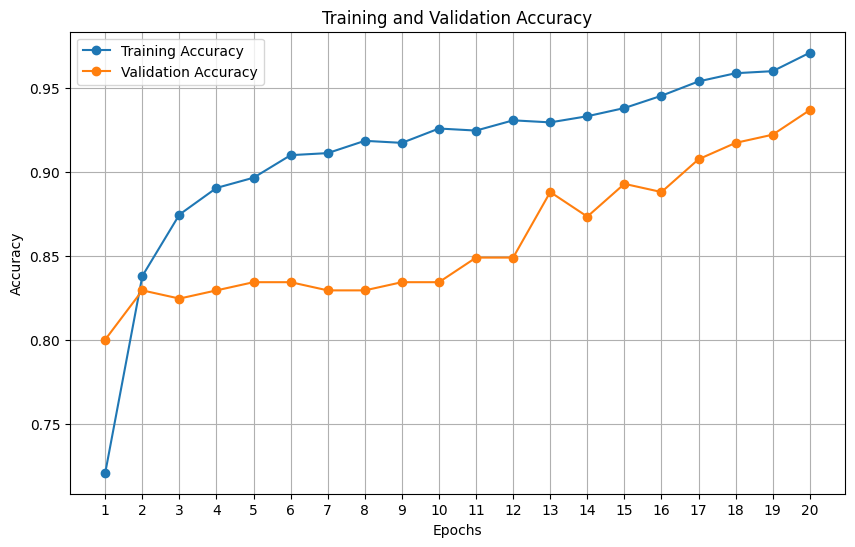

In [ ]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(10, 6))

# Plot training and validation accuracy from the 'history' object
plt.plot(range(1, 21), history.history['accuracy'], marker='o', label='Training Accuracy')
plt.plot(range(1, 21), history.history['val_accuracy'], marker='o', label='Validation Accuracy')

# Add titles and labels
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(range(1, 21)) # Ensure x-axis shows integer epochs

# Add legend and grid
plt.legend()
plt.grid(True)

# Display the plot
plt.show()

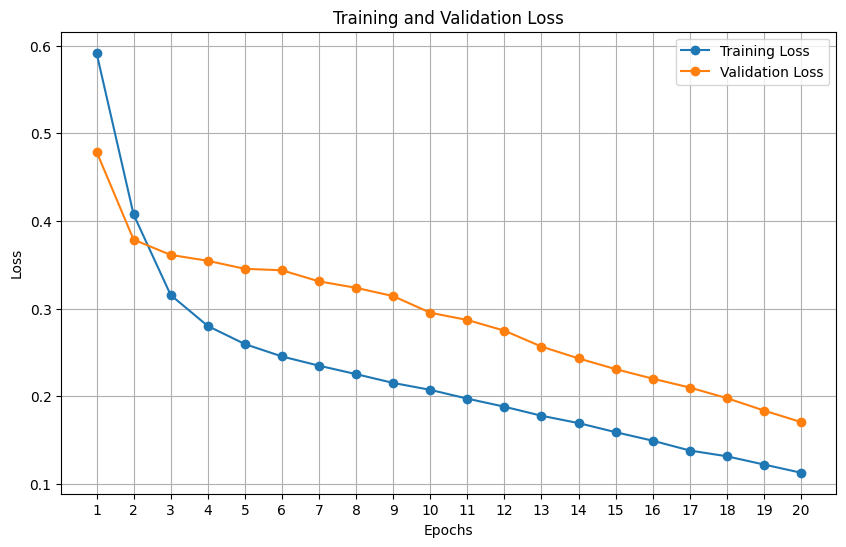

In [ ]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(10, 6))

# Plot training and validation loss from the 'history' object
plt.plot(range(1, 21), history.history['loss'], marker='o', label='Training Loss')
plt.plot(range(1, 21), history.history['val_loss'], marker='o', label='Validation Loss')

# Add titles and labels
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(range(1, 21)) # Ensure x-axis shows integer epochs

# Add legend and grid
plt.legend()
plt.grid(True)

# Display the plot
plt.show()